In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os
from torch.utils.tensorboard import SummaryWriter

### Настройка устройства

In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')

print(f"Используется устройство: {device}")

Используется устройство: cpu


Создаем папку для результатов

In [39]:
os.makedirs('results', exist_ok=True)
os.makedirs('runs', exist_ok=True)

writer = SummaryWriter('runs/vae_experiment')

### Подготовка датасета

In [40]:
BATCH_SIZE = 128
IMAGE_SIZE = 32

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
])

### Скачиваем KMNIST (японские иероглифы)

In [41]:
train_dataset = datasets.KMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.KMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Размер обучающего датасета: {len(train_dataset)} примеров")
print(f"Размер тестового датасета: {len(test_dataset)} примеров")
print(f"Размер изображений: {IMAGE_SIZE}x{IMAGE_SIZE}")

Размер обучающего датасета: 60000 примеров
Размер тестового датасета: 10000 примеров
Размер изображений: 32x32


### Визуализация примеров из датасета

In [42]:
def show_images(images, title="Примеры"):
    if len(images) == 1:
        fig, ax = plt.subplots(1, 1, figsize=(3, 3))
        ax.imshow(images[0].squeeze(), cmap='gray')
        ax.axis('off')
        ax.set_title(title)
    else:
        fig, axes = plt.subplots(1, len(images), figsize=(12, 3))
        for i, img in enumerate(images):
            axes[i].imshow(img.squeeze(), cmap='gray')
            axes[i].axis('off')
        plt.suptitle(title)
    plt.show()

### Посмотрим на реальные иероглифы

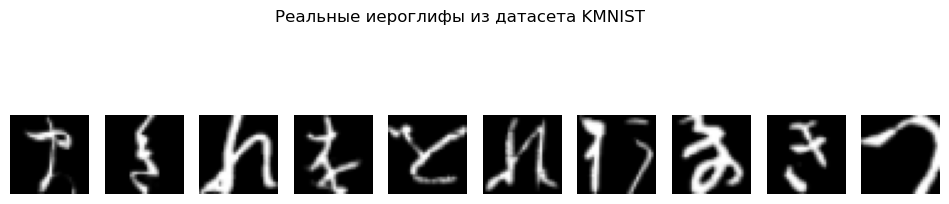

In [43]:
examples = next(iter(train_loader))[0][:10]
show_images(examples, "Реальные иероглифы из датасета KMNIST")

### Реализация VAE

In [46]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)
        z = self.decoder_input(z)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar

### Инициализация модели

In [47]:
latent_dim = 32
model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### Обучение

Функция потерь

In [48]:
def loss_function(recon_x, x, mu, logvar):

    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

Цикл обучения

In [49]:
EPOCHS = 20
model.train()
loss_history = []

print("Начинаем обучение...")

for epoch in range(EPOCHS):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            global_step = epoch * len(train_loader) + batch_idx
            writer.add_scalar('Loss/Batch', loss.item() / len(data), global_step)

    avg_loss = train_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    
    writer.add_scalar('Loss/Epoch', avg_loss, epoch)
    
    print(f'Epoch: {epoch+1} | Loss: {avg_loss:.4f}')

writer.close()
print("\nОбучение завершено! Для просмотра метрик в TensorBoard выполните: tensorboard --logdir=runs")

Начинаем обучение...
Epoch: 1 | Loss: 328.9986
Epoch: 2 | Loss: 266.8340
Epoch: 3 | Loss: 261.8866
Epoch: 4 | Loss: 259.3579
Epoch: 5 | Loss: 257.6902
Epoch: 6 | Loss: 256.5509
Epoch: 7 | Loss: 255.6797
Epoch: 8 | Loss: 254.9287
Epoch: 9 | Loss: 254.2577
Epoch: 10 | Loss: 253.7409
Epoch: 11 | Loss: 253.3367
Epoch: 12 | Loss: 252.8683
Epoch: 13 | Loss: 252.5196
Epoch: 14 | Loss: 252.2145
Epoch: 15 | Loss: 251.9344
Epoch: 16 | Loss: 251.6210
Epoch: 17 | Loss: 251.3872
Epoch: 18 | Loss: 251.1595
Epoch: 19 | Loss: 250.9718
Epoch: 20 | Loss: 250.8514
Epoch: 21 | Loss: 250.5133
Epoch: 22 | Loss: 250.3396
Epoch: 23 | Loss: 250.2823
Epoch: 24 | Loss: 250.0724
Epoch: 25 | Loss: 249.8919
Epoch: 26 | Loss: 249.8090
Epoch: 27 | Loss: 249.6884
Epoch: 28 | Loss: 249.4872
Epoch: 29 | Loss: 249.4040
Epoch: 30 | Loss: 249.3212

Обучение завершено! Для просмотра метрик в TensorBoard выполните: tensorboard --logdir=runs


График функции потерь

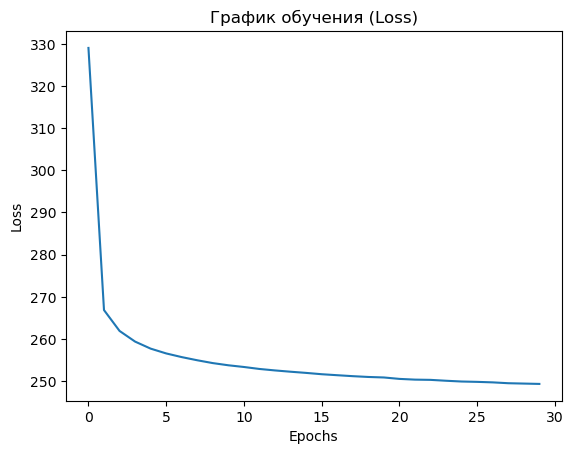

In [50]:
plt.plot(loss_history)
plt.title("График обучения (Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### Визуализация реконструкций


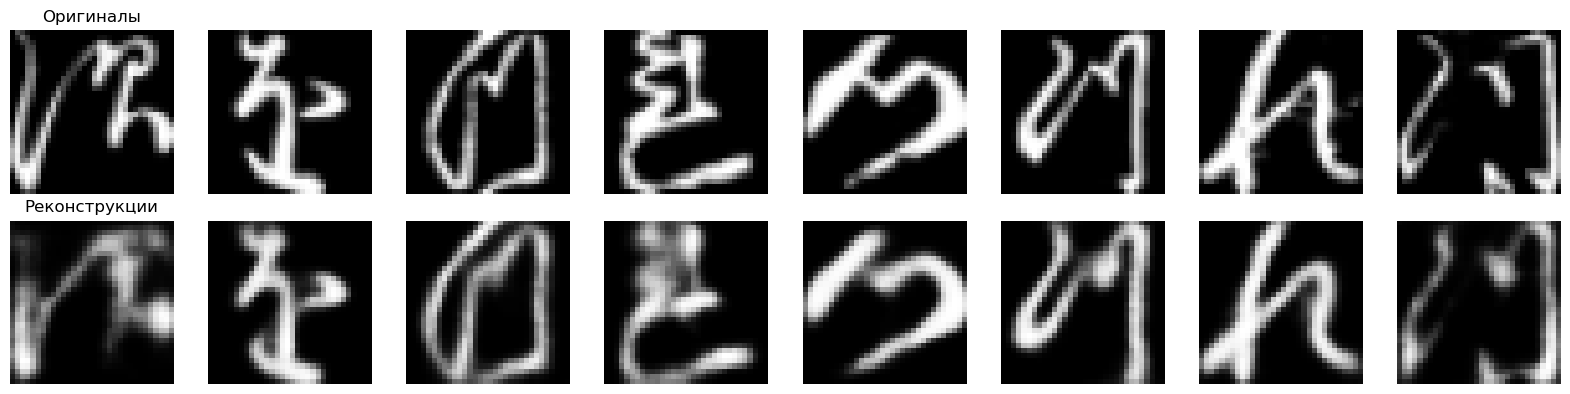

In [51]:
model.eval()
with torch.no_grad():
    test_batch = next(iter(test_loader))[0][:8].to(device)
    recon_batch, _, _ = model(test_batch)
    
    comparison = torch.cat([test_batch[:8], recon_batch[:8]], dim=0)
    comparison = comparison.cpu()
    
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        axes[0, i].imshow(comparison[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Оригиналы', fontsize=12)
        
        axes[1, i].imshow(comparison[i+8].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Реконструкции', fontsize=12)
    
    plt.tight_layout()
    plt.show()


### Генерация новых примеров

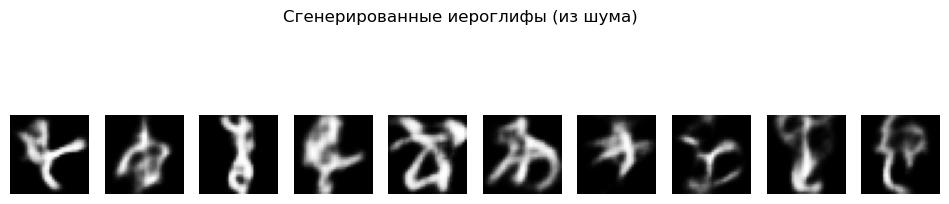

In [52]:
model.eval()

def generate_random_hieroglyphs(num_images=10):
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim).to(device)
        z = model.decoder_input(z)
        generated = model.decoder(z).cpu()
    show_images(generated, "Сгенерированные иероглифы (из шума)")

generate_random_hieroglyphs(10)

Создание GIF с интерполяцией

In [56]:
def interpolate_points(p1, p2, n_steps=10):

    if p1.dim() > 1:
        p1 = p1.squeeze()
    if p2.dim() > 1:
        p2 = p2.squeeze()
    
    ratios = np.linspace(0, 1, num=n_steps)
    vectors = []
    for ratio in ratios:
        v = (1.0 - ratio) * p1 + ratio * p2
        vectors.append(v)
    result = torch.stack(vectors)
    return result

In [64]:
def create_gif(model, dataset, filename='hieroglyph_morph.gif', num_preview_images=8, steps=40):

    model.eval()

    idx1, idx2 = np.random.randint(0, len(dataset), 2)
    img_A, _ = dataset[idx1]
    img_B, _ = dataset[idx2]

    img_A = img_A.unsqueeze(0).to(device)
    img_B = img_B.unsqueeze(0).to(device)

    with torch.no_grad():
        encoded_A = model.encoder(img_A)
        mu_A = model.fc_mu(encoded_A)

        encoded_B = model.encoder(img_B)
        mu_B = model.fc_mu(encoded_B)

    mu_A_flat = mu_A.squeeze(0)
    mu_B_flat = mu_B.squeeze(0)
    
    assert mu_A_flat.shape == (model.latent_dim,), f"mu_A_flat имеет неправильную размерность: {mu_A_flat.shape}"
    assert mu_B_flat.shape == (model.latent_dim,), f"mu_B_flat имеет неправильную размерность: {mu_B_flat.shape}"
    
    interpolated_z = interpolate_points(mu_A_flat, mu_B_flat, steps).to(device)
    
    assert interpolated_z.shape == (steps, model.latent_dim), f"Неправильная размерность interpolated_z: {interpolated_z.shape}, ожидается ({steps}, {model.latent_dim})"

    images_for_gif = []
    with torch.no_grad():
        z_decoder_input = model.decoder_input(interpolated_z)
        
        expected_size = 128 * 4 * 4
        if z_decoder_input.shape[1] != expected_size:
            raise RuntimeError(
                f"Ошибка размерности decoder_input: ожидалась размерность {expected_size}, "
                f"получена {z_decoder_input.shape[1]}. Форма тензора: {z_decoder_input.shape}. "
                f"Входной тензор имел форму: {interpolated_z.shape}, latent_dim модели: {model.latent_dim}"
            )
        
        generated_imgs = model.decoder(z_decoder_input).cpu()

    print(f"Трансформация из А в Б (показываем {num_preview_images} промежуточных изображений):")
    
    preview_indices = np.linspace(0, steps - 1, num_preview_images, dtype=int)
    
    fig, axes = plt.subplots(1, num_preview_images, figsize=(num_preview_images * 1.5, 2))
    
    if num_preview_images == 1:
        axes = [axes]
    
    for i, idx in enumerate(preview_indices):
        img = generated_imgs[idx].squeeze().numpy()
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'Шаг {idx}', fontsize=10)
    
    plt.tight_layout()
    plt.show()

    for i in range(steps):
        img = generated_imgs[i].squeeze().numpy()
        img = (img * 255).astype(np.uint8)
        images_for_gif.append(img)

    imageio.mimsave(filename, images_for_gif, fps=10)


Трансформация из А в Б (показываем 8 промежуточных изображений):


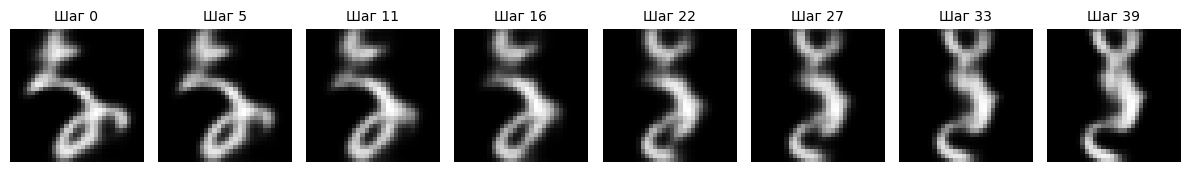

Трансформация из А в Б (показываем 8 промежуточных изображений):


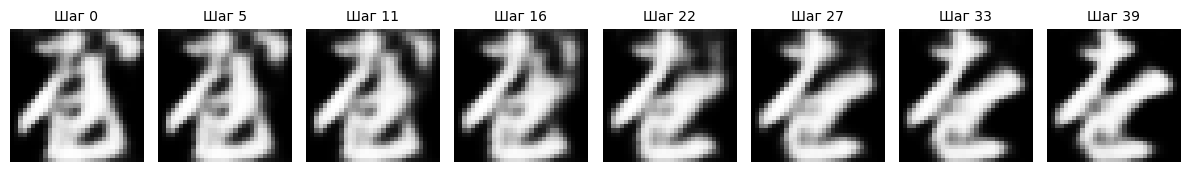

Трансформация из А в Б (показываем 8 промежуточных изображений):


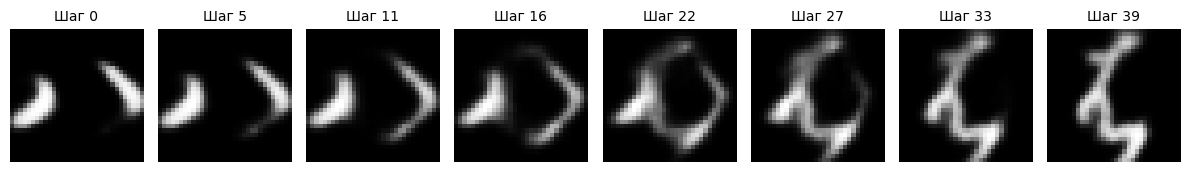

Трансформация из А в Б (показываем 8 промежуточных изображений):


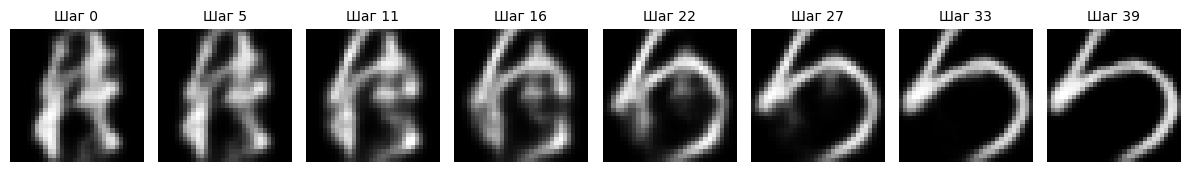

Трансформация из А в Б (показываем 8 промежуточных изображений):


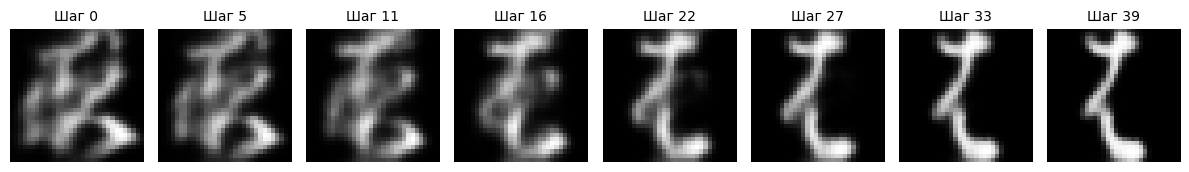

Трансформация из А в Б (показываем 8 промежуточных изображений):


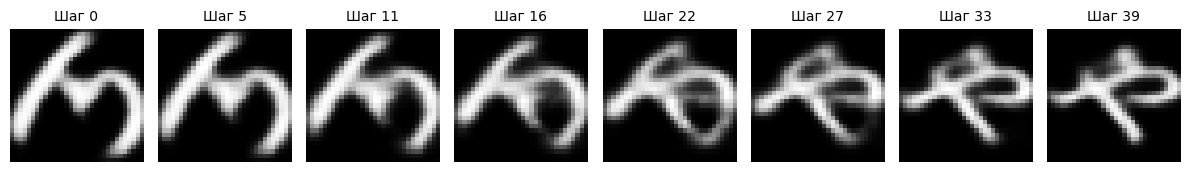

Трансформация из А в Б (показываем 8 промежуточных изображений):


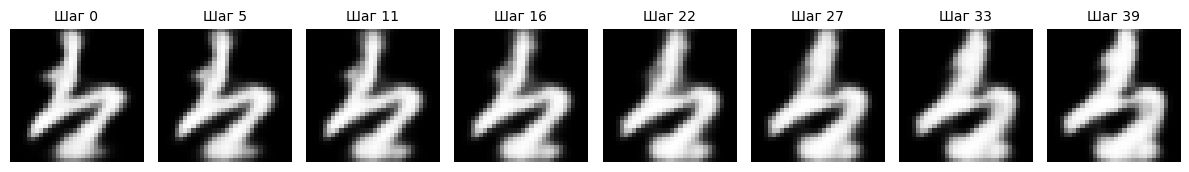

Трансформация из А в Б (показываем 8 промежуточных изображений):


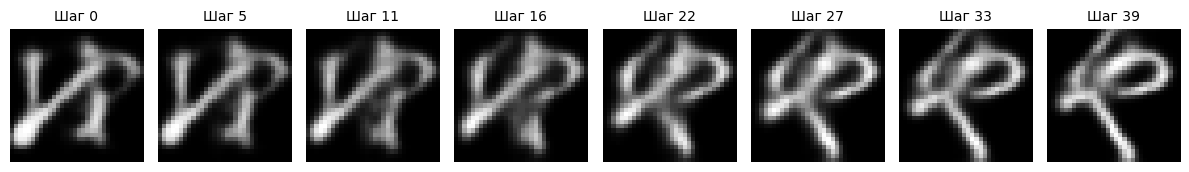

In [65]:
for i in range(8):
    create_gif(model, test_dataset, num_preview_images=8, steps=40)